# REDES CONVOLUCIONALES (CCNN)

Las **redes convolucionales** son un tipo de redes neuronales diseñadas para procesar **datos con estructura de malla**, como las **imágenes**.

En este notebook vamos a partir de un dataset de imágenes de satélite. Vamos a realizar el tratamiento adecuado y vamos a crear un modeo base y uno a partir de la arquitectura de una de las redes conocidas en este campo, evaluando el desempeño de cada uno.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import cv2
import os

import warnings
warnings.filterwarnings('ignore')



import tensorflow as tf



Montamos nuestra cuenta de Google Drive:

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


## Carga de los datos

Es muy común descargar los datos desde repositorios o páginas de datos abiertos. Además entre ellas hay ciertas páginas que almacenan datasets conocidos y en la forma apropiada para su uso (problema de la etiquetación de imágenes).

Uno de ellos es **"Kaggle"**. El **dataset** que nos interesa lo encontramos con **las distintas categorias en subcarpetas de las carpetas "train" y "test"**.

Para descargarlas hay que tener una **cuenta en Kaggle activa** y para la autenticación **descargarse un API TOKEN** (en nuestro logo de usuario a la derecha ir a Configuración, y en el apartado de API darle al botón de "Nuevo Token").

Según las instrucciones debemos subir ese archivo "json"que se nos descarga a una carpeta que crearemos en nuestro DRIVE, en "MyDrive", al que le pondemos de nombre "Kaggle".

Por último añadir las lineas de código:



In [ ]:
import os

os.environ['KAGGLE_CONFIG_DIR'] = "/content/gdrive/MyDrive/Kaggle"



Ahora solo falta ir a la  [página del dataset](https://www.kaggle.com/datasets/happyyang/ucmerced-landuse-50-split) y a la derecha, al lado del botón Descargar, picar en los 3 puntos y elegir "Copy API Command", que pegamos en la celda:



In [ ]:
!kaggle datasets download -d happyyang/ucmerced-landuse-50-split

100% 317M/317M [00:04<00:00, 33.1MB/s]
100% 317M/317M [00:04<00:00, 78.5MB/s]


Una vez descargado descomprimimos:

In [ ]:
!unzip ucmerced-landuse-50-split.zip

Archive:  ucmerced-landuse-50-split.zip
  inflating: split/test/agricultural/agricultural03.tif  
  inflating: split/test/agricultural/agricultural04.tif  
  inflating: split/test/agricultural/agricultural05.tif  
  inflating: split/test/agricultural/agricultural06.tif  
  inflating: split/test/agricultural/agricultural08.tif  
  inflating: split/test/agricultural/agricultural10.tif  
  inflating: split/test/agricultural/agricultural11.tif  
  inflating: split/test/agricultural/agricultural12.tif  
  inflating: split/test/agricultural/agricultural13.tif  
  inflating: split/test/agricultural/agricultural14.tif  
  inflating: split/test/agricultural/agricultural23.tif  
  inflating: split/test/agricultural/agricultural24.tif  
  inflating: split/test/agricultural/agricultural28.tif  
  inflating: split/test/agricultural/agricultural30.tif  
  inflating: split/test/agricultural/agricultural33.tif  
  inflating: split/test/agricultural/agricultural34.tif  
  inflating: split/test/agricult

**Y ya tenemos en nuestra sesión el dataset de imagenes ordenadas en subcarpetas.**

In [ ]:
train_dataset_path = '/content/split/train'
test_dataset_path = '/content/split/test'

In [ ]:
# valores imágenes

IMG_WIDTH = 256
IMG_HEIGHT = 256

BATCH_SIZE = 32

Nos valdremos de la clase ["ImageDataGenerator"](https://blog.keras.io/building-powerful-image-classification-models-using-very-little-data.html) de Keras para crear dos generadores de imágenes que nos proporcionarán respectivamente las imágenes de TRAIN y VALIDATION.

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale=1.0/255,
                                   zoom_range=0.2,
                                   width_shift_range=0.2,
                                   height_shift_range=0.2,
                                   fill_mode='nearest')

train_generator = train_datagen.flow_from_directory(train_dataset_path,
                                                    target_size=(IMG_WIDTH, IMG_HEIGHT),
                                                    batch_size=BATCH_SIZE,
                                                    class_mode='categorical',
                                                    shuffle=True)

Found 1050 images belonging to 21 classes.


In [ ]:
validation_datagen = ImageDataGenerator(rescale=1.0/255)

validation_generator = validation_datagen.flow_from_directory(test_dataset_path,
                                                              target_size=(IMG_WIDTH, IMG_HEIGHT),
                                                              batch_size=BATCH_SIZE,
                                                              class_mode='categorical',
                                                              shuffle=True)

Found 1050 images belonging to 21 classes.


**Veamos como estan etiquetadas las imágenes:**

In [ ]:
labels = {value: key for key, value in train_generator.class_indices.items()}

for key, value in labels.items():
    print(f"{key} : {value}")


0 : agricultural
1 : airplane
2 : baseballdiamond
3 : beach
4 : buildings
5 : chaparral
6 : denseresidential
7 : forest
8 : freeway
9 : golfcourse
10 : harbor
11 : intersection
12 : mediumresidential
13 : mobilehomepark
14 : overpass
15 : parkinglot
16 : river
17 : runway
18 : sparseresidential
19 : storagetanks
20 : tenniscourt


Y vamos a echar un vistazo a **algunas de las categorias:**

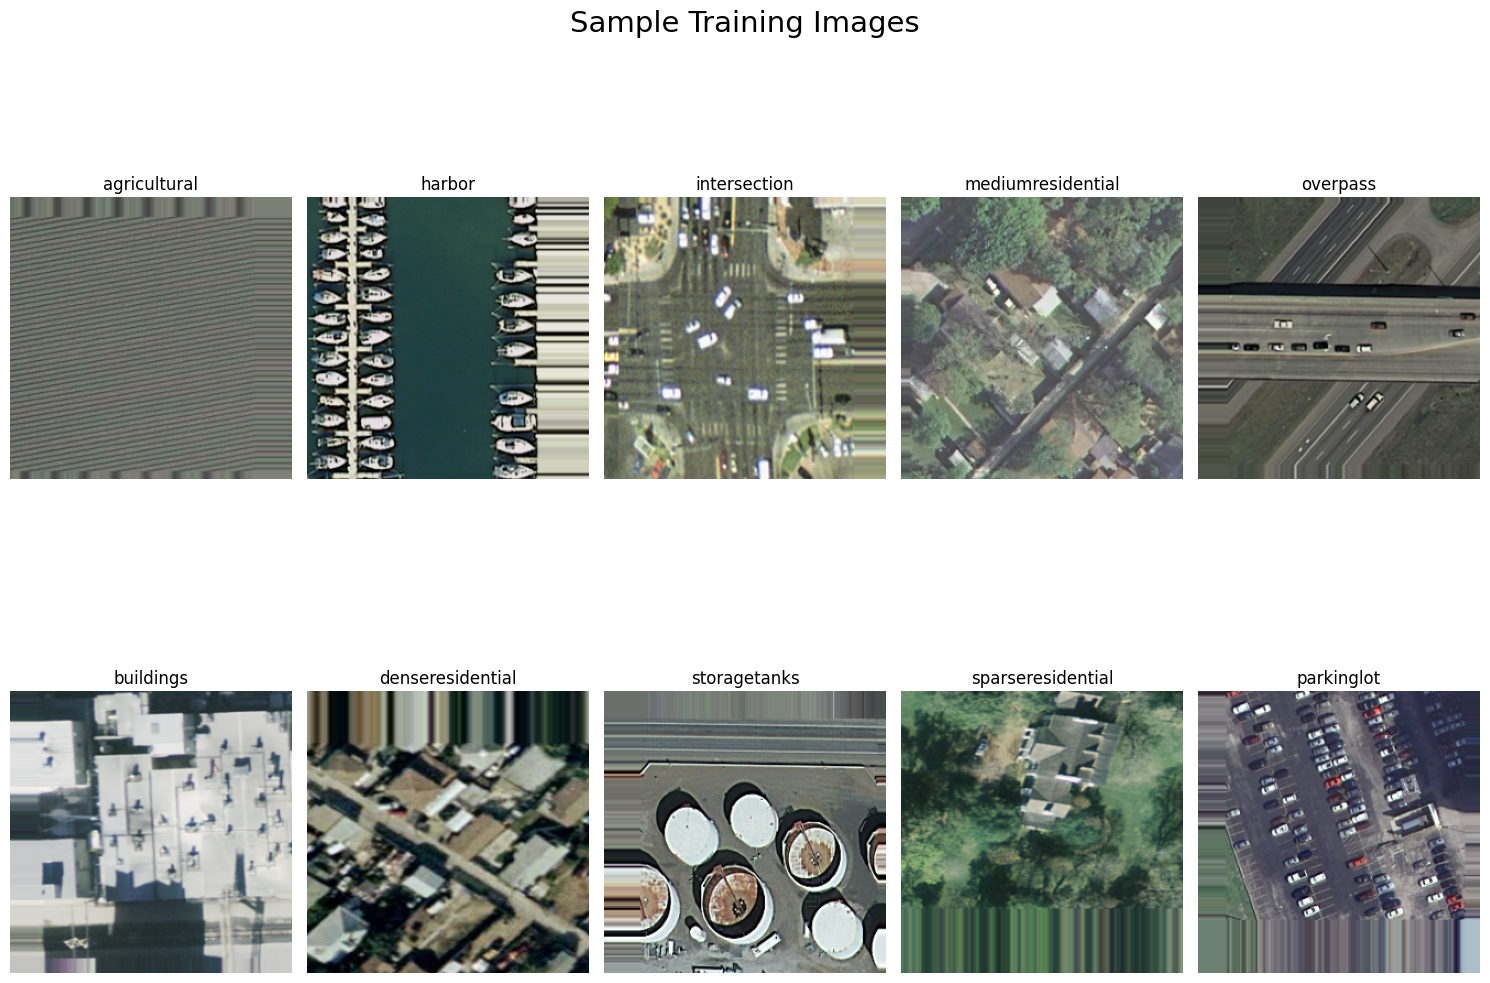

In [ ]:
fig, ax = plt.subplots(nrows=2, ncols=5, figsize=(15, 12))
idx = 0

for i in range(2):
    for j in range(5):
        label = labels[np.argmax(train_generator[0][1][idx])]
        ax[i, j].set_title(f"{label}")
        ax[i, j].imshow(train_generator[0][0][idx][:, :, :])
        ax[i, j].axis("off")
        idx += 1

plt.tight_layout()
plt.suptitle("Sample Training Images", fontsize=21)
plt.show()

##MODELO BASE: red CNN sencilla

Partimos como modelo base de una red convolucional sencilla:

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import BatchNormalization, Conv2D, Dense, Dropout, Flatten, MaxPooling2D, InputLayer


# el tamaño de 256x256 de las imágenes originales elevaría exponencialmente los parámetros a aprender
# y por lo tanto los tiempos ya largos de entrenamiento. Solución: capa "Resizing"
from tensorflow.keras.layers import Resizing




In [ ]:
modelo_base = Sequential()


# Feature Extractor

modelo_base.add(InputLayer(input_shape=(IMG_WIDTH, IMG_HEIGHT,3),name='image'))
modelo_base.add(Resizing(32,32))

modelo_base.add(Conv2D(filters=128, kernel_size=(5, 5), padding='valid',activation="relu"))
modelo_base.add(MaxPooling2D(pool_size=(2, 2)))
modelo_base.add(BatchNormalization())

modelo_base.add(Conv2D(filters=64, kernel_size=(3, 3), padding='valid',activation="relu"))
modelo_base.add(MaxPooling2D(pool_size=(2, 2)))
modelo_base.add(BatchNormalization())

modelo_base.add(Conv2D(filters=32, kernel_size=(3, 3), padding='valid', activation="relu"))
modelo_base.add(MaxPooling2D(pool_size=(2, 2)))
modelo_base.add(BatchNormalization())


# Clasificador
modelo_base.add(Flatten())
modelo_base.add(Dense(256, activation="relu", kernel_initializer="he_normal", bias_initializer="zeros"))
modelo_base.add(Dropout(0.5))

modelo_base.add(Dense(21, activation="softmax", kernel_initializer="glorot_normal", bias_initializer="zeros"))




In [ ]:
modelo_base.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resizing (Resizing)         (None, 32, 32, 3)         0         
                                                                 
 conv2d (Conv2D)             (None, 28, 28, 128)       9728      
                                                                 
 max_pooling2d (MaxPooling2  (None, 14, 14, 128)       0         
 D)                                                              
                                                                 
 batch_normalization (Batch  (None, 14, 14, 128)       512       
 Normalization)                                                  
                                                                 
 conv2d_1 (Conv2D)           (None, 12, 12, 64)        73792     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 6, 6, 64)          0

In [ ]:
from tensorflow.keras.optimizers import Adam

# nota: learning rate bajo
modelo_base.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])



In [ ]:
history_base = modelo_base.fit(train_generator, epochs=50, validation_data=validation_generator, verbose=2)

Epoch 1/50
33/33 - 30s - loss: 3.5561 - accuracy: 0.1229 - val_loss: 3.0800 - val_accuracy: 0.0552 - 30s/epoch - 920ms/step
Epoch 2/50
33/33 - 16s - loss: 2.8841 - accuracy: 0.2076 - val_loss: 3.0676 - val_accuracy: 0.0810 - 16s/epoch - 498ms/step
Epoch 3/50
33/33 - 17s - loss: 2.4703 - accuracy: 0.2648 - val_loss: 3.1800 - val_accuracy: 0.0562 - 17s/epoch - 513ms/step
Epoch 4/50
33/33 - 16s - loss: 2.3298 - accuracy: 0.3133 - val_loss: 3.4653 - val_accuracy: 0.0505 - 16s/epoch - 495ms/step
Epoch 5/50
33/33 - 16s - loss: 2.2379 - accuracy: 0.3248 - val_loss: 4.0221 - val_accuracy: 0.0476 - 16s/epoch - 485ms/step
Epoch 6/50
33/33 - 16s - loss: 2.0259 - accuracy: 0.3524 - val_loss: 4.0053 - val_accuracy: 0.0476 - 16s/epoch - 481ms/step
Epoch 7/50
33/33 - 16s - loss: 2.0358 - accuracy: 0.3590 - val_loss: 4.2468 - val_accuracy: 0.0476 - 16s/epoch - 480ms/step
Epoch 8/50
33/33 - 16s - loss: 1.9330 - accuracy: 0.3886 - val_loss: 4.7724 - val_accuracy: 0.0476 - 16s/epoch - 482ms/step
Epoch 9/

Utilizamos de nuevo la función del tema anterior para dibujar las curvas:

In [ ]:
def plot_train_results(history):

    # Visualizamos la evolución de la accuracy
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('model accuracy')
    plt.ylabel('accuracy')
    plt.xlabel('epoch')
    plt.legend(['train', 'test'], loc='lower right')
    plt.grid = True
    plt.show()

    # Visualizamos la evolución del error cometido por la red
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('model loss')
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend(['train', 'test'], loc='upper right')
    plt.grid = True
    plt.show()

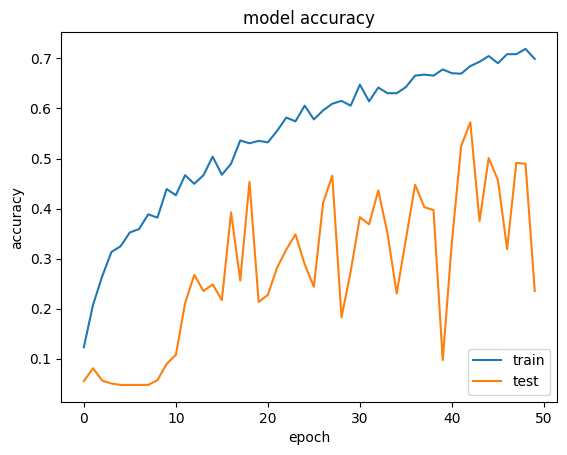

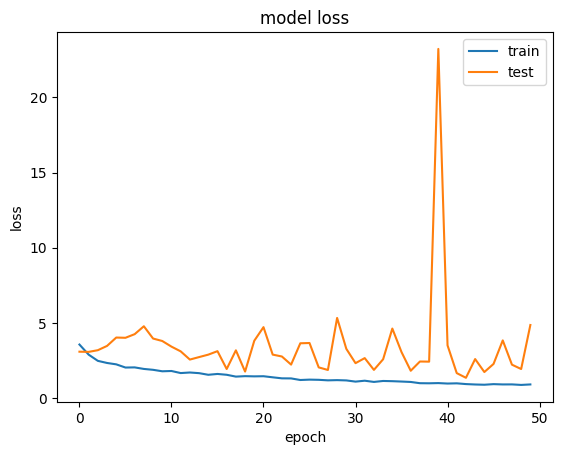

In [ ]:
plot_train_results(history_base)

Observamos inestabilidad. **Con learnin-rate bajo y batch size adecuado nos podemos aventurar que es debido a la sencillez del modelo**, que no termina de "capturar" los patrones de las imágenes.

Veamos el valor de "accuracy" alcanzado:

In [ ]:
loss, accuracy = modelo_base.evaluate(validation_generator, batch_size=BATCH_SIZE)

print(f"Test Loss:     {loss}")
print(f"Test Accuracy: {accuracy}")

33/33 [==============================] - 2s 48ms/step - loss: 4.8562 - accuracy: 0.2352
Test Loss:     4.856176376342773
Test Accuracy: 0.23523809015750885


###Mapa de características

Podemos extraer de una de las **capas de convolución** de nuestro modelo un **mapa de características** para una instancia (imágen).

Para mayor detalle elegimos la **última** que nos proporciona las **características de alto nivel**:

In [ ]:
modelo_base.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resizing (Resizing)         (None, 32, 32, 3)         0         
                                                                 
 conv2d (Conv2D)             (None, 28, 28, 128)       9728      
                                                                 
 max_pooling2d (MaxPooling2  (None, 14, 14, 128)       0         
 D)                                                              
                                                                 
 batch_normalization (Batch  (None, 14, 14, 128)       512       
 Normalization)                                                  
                                                                 
 conv2d_1 (Conv2D)           (None, 12, 12, 64)        73792     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 6, 6, 64)          0

In [ ]:
# Lo tenemos que "expresar" como modelo
from keras import Model

layer_out = modelo_base.get_layer("conv2d_2")
intermediate_layer_model = Model(inputs=modelo_base.input,outputs=layer_out.output)



/content/split/test/airplane/airplane21.tif


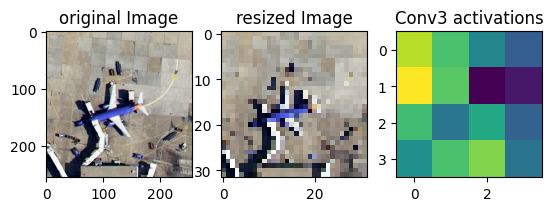

In [ ]:
# CÓDIGO PARA RECUPERAR MAPA DE CARACTERÍSTICAS DE UNA CLASE (AVIÓN)

path_data = '/content/split/test'
c = 'airplane'
filenames_validation = [os.path.join(path_data, f) for f in validation_generator.filenames if c in f]
np.random.shuffle(filenames_validation)
print(filenames_validation[0])
image = cv2.imread(filenames_validation[0])
image_vis = cv2.resize(image, (32,32))

# normalize image
x = image.astype(np.float)/255

# extract features
features = intermediate_layer_model(np.expand_dims(x, 0)).numpy()[0]

# sum activation across channels
activations = features.sum(-1)

# display original and activations
plt.subplot(1,3,1), plt.imshow(image[:,:,::-1])
plt.title('original Image')
plt.subplot(1,3,2), plt.imshow(image_vis[:,:,::-1])
plt.title('resized Image')
plt.subplot(1,3,3), plt.imshow(activations)
plt.title('Conv3 activations')
plt.show()


## MODELO A APARTIR DE UNO CONOCIDO: FEATURE EXTRACCION

Como **primer modelo** vamos a usar el método **FEATURE EXTRACTION dentro del campo de TRANSFER LEARNING**. Vamos a partir de una **red ya preentrenada (conjunto de imágenes ['Imagenet'](https://www.image-net.org/update-mar-11-2021.php))**, de la que **sólo prescindiremos de sus capas FC, del clasificador final**. Añadiremos nosotros el nuestro particular y entrenaremos el modelo resultante.**


De esta forma sólo tendremos como parámetros entrenables los del clasificador final (capas FC) que hemos añadido, aprovechándonos de los pesos de las capas anteriores ya adquiridos (con 'Imagenet'), es decir **ya el modelo partirá de un conjunto de características aprendido**. En nuestro caso particular nos viene bien dado el número bajo de imágenes del que disponemos, si bien dada la generalidad y variedad del conjunto 'Imagenet' frente a nuestro caso particular de radiografías, habremos de evaluar el resultado.

In [ ]:
from keras.applications import VGG16

# include_top= False para prescindir de las capas FC y preentrenamiento con cjto de imágenes 'Imagenet'
cnn_base = VGG16(weights='imagenet', include_top=False, input_shape=(IMG_WIDTH, IMG_HEIGHT, 3))



58889256/58889256 [==============================] - 4s 0us/step


Creamos nuestro modelo, "congelando" la base VGG (trainable=False):

In [ ]:
from keras.optimizers import RMSprop

cnn_base.trainable = False

# MODELO FE (feature extraction)
modelo_fe = Sequential()

# podemos añadir como "capa" un modelo
modelo_fe.add(cnn_base)

modelo_fe.add(Flatten())
modelo_fe.add(Dense(512, activation='relu'))
modelo_fe.add(Dense(21, activation='softmax'))

modelo_fe.compile(loss='categorical_crossentropy', optimizer=RMSprop(learning_rate=1e-5), metrics=['acc'])



In [ ]:
modelo_fe.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 8, 8, 512)         14714688  
                                                                 
 flatten_1 (Flatten)         (None, 32768)             0         
                                                                 
 dense_2 (Dense)             (None, 512)               16777728  
                                                                 
 dense_3 (Dense)             (None, 21)                10773     
                                                                 
Total params: 31503189 (120.18 MB)
Trainable params: 16788501 (64.04 MB)
Non-trainable params: 14714688 (56.13 MB)
_________________________________________________________________


Podemos comprobar en el resumen que **el número de parámetros no entrenable ("congelado") coincide con los de la base VGG.**

Es recomendable "resetear" los generadores si ya han sido utilizados antes de un nuevo uso.

In [ ]:
train_generator.reset()
validation_generator.reset()

Entrenamos finalmente el modelo:

In [ ]:
mod_fe_fit = modelo_fe.fit_generator(train_generator, epochs=30, validation_data=validation_generator, verbose=1)


Epoch 1/30
33/33 [==============================] - 17s 469ms/step - loss: 2.8010 - acc: 0.2352 - val_loss: 2.4282 - val_acc: 0.4114
Epoch 2/30
33/33 [==============================] - 16s 486ms/step - loss: 2.2716 - acc: 0.4695 - val_loss: 1.9595 - val_acc: 0.6143
Epoch 3/30
33/33 [==============================] - 16s 485ms/step - loss: 1.8769 - acc: 0.5810 - val_loss: 1.6205 - val_acc: 0.6600
Epoch 4/30
33/33 [==============================] - 16s 484ms/step - loss: 1.5610 - acc: 0.6952 - val_loss: 1.3865 - val_acc: 0.6943
Epoch 5/30
33/33 [==============================] - 16s 481ms/step - loss: 1.3767 - acc: 0.7248 - val_loss: 1.1990 - val_acc: 0.7305
Epoch 6/30
33/33 [==============================] - 16s 483ms/step - loss: 1.1716 - acc: 0.7657 - val_loss: 1.0517 - val_acc: 0.7524
Epoch 7/30
33/33 [==============================] - 16s 492ms/step - loss: 1.0576 - acc: 0.7905 - val_loss: 0.9662 - val_acc: 0.7505
Epoch 8/30
33/33 [==============================] - 16s 492ms/step - 

**NOTA:** hubo que corregir ligeramente el código de la función que dibuja las curvas de entrenamiento (solo cambiar algunos nombres de variables):

In [ ]:
mod_fe_fit.history.keys()

dict_keys(['loss', 'acc', 'val_loss', 'val_acc'])

In [ ]:
def plot_train_results2(history):

    # Visualizamos la evolución de la accuracy
    plt.plot(history.history['acc'])
    plt.plot(history.history['val_acc'])
    plt.title('model accuracy')
    plt.ylabel('accuracy')
    plt.xlabel('epoch')
    plt.legend(['train', 'test'], loc='lower right')
    plt.grid = True
    plt.show()

    # Visualizamos la evolución del error cometido por la red
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('model loss')
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend(['train', 'test'], loc='upper right')
    plt.grid = True
    plt.show()

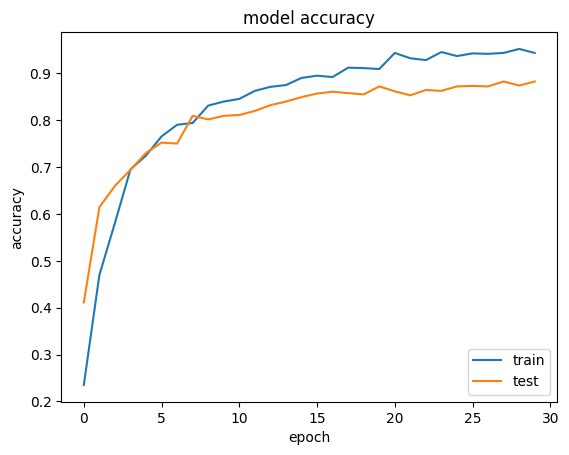

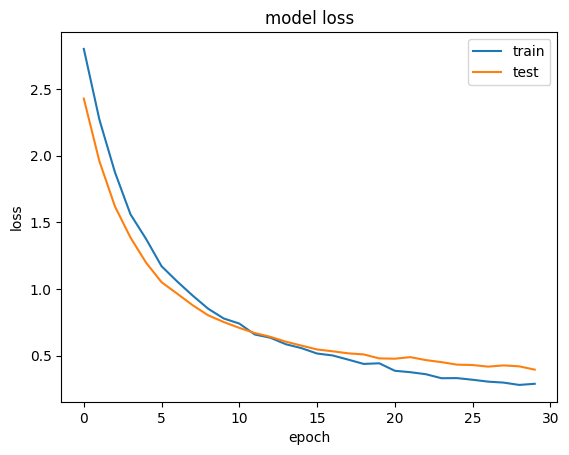

In [ ]:
plot_train_results2(mod_fe_fit)

Si comparamos estas curvas con las del modelo base, aparte de las cifras alcanzadas, **el trazado es más suave (sin oscilaciones) como se corresponde con un modelo tan estable y "profundo" como el VGG**.

Veamos el valor de "accuracy" alcanzado:

In [ ]:
loss, accuracy = modelo_fe.evaluate(validation_generator, batch_size=BATCH_SIZE)

print(f"Test Loss:     {loss}")
print(f"Test Accuracy: {accuracy}")

33/33 [==============================] - 2s 55ms/step - loss: 0.3961 - acc: 0.8829
Test Loss:     0.39608463644981384
Test Accuracy: 0.8828571438789368


###Mapa de características

Extraemos ahora un mapa de características de este modelo. Lo haremos del modelo "cnn_base" con VGG:

In [ ]:
modelo_fe.summary()


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 8, 8, 512)         14714688  
                                                                 
 flatten_1 (Flatten)         (None, 32768)             0         
                                                                 
 dense_2 (Dense)             (None, 512)               16777728  
                                                                 
 dense_3 (Dense)             (None, 21)                10773     
                                                                 
Total params: 31503189 (120.18 MB)
Trainable params: 16788501 (64.04 MB)
Non-trainable params: 14714688 (56.13 MB)
_________________________________________________________________


In [ ]:
cnn_base.summary()

Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 256, 256, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 256, 256, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 256, 256, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 128, 128, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 128, 128, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 128, 128, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 64, 64, 128)       0     

In [ ]:
# Define the feature extraction
from keras import Model

layer_out = cnn_base.get_layer("block5_conv3")
intermediate_layer_model = Model(inputs=cnn_base.input,outputs=layer_out.output)



/content/split/test/airplane/airplane07.tif


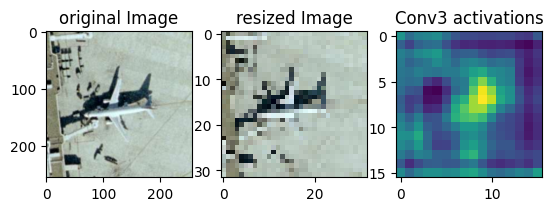

In [ ]:
# Load random image from the category specific category

path_data = '/content/split/test'
c = 'airplane'
filenames_validation = [os.path.join(path_data, f) for f in validation_generator.filenames if c in f]
np.random.shuffle(filenames_validation)
print(filenames_validation[0])
image = cv2.imread(filenames_validation[0])
image_vis = cv2.resize(image, (32,32))

# normalize image
x = image.astype(np.float)/255

# extract features
features = intermediate_layer_model(np.expand_dims(x, 0)).numpy()[0]

# sum activation across channels
activations = features.sum(-1)

# display original and activations
plt.subplot(1,3,1), plt.imshow(image[:,:,::-1])
plt.title('original Image')
plt.subplot(1,3,2), plt.imshow(image_vis[:,:,::-1])
plt.title('resized Image')
plt.subplot(1,3,3), plt.imshow(activations)
plt.title('Conv3 activations')
plt.show()


##MODELO A PARTIR DE UNO CONOCIDO: FINE TUNNING

Para este segundo modelo **"descongelaremos" en este caso las últimas capas convolucionales del modelo base VGG, para poder así entrenar también esta última parte. Dentro del Transfer Learning es el método FINE TUNNING.**

De esta forma esta vez no nos quedaremos con todas las características aprendidas del modelo preentrenado, y una parte de la red base se entrenará con nuestro conjunto particular de datos. Por decirlo de otra forma **nos quedaremos con ciertas características de nivel menor ya aprendidas mientras que intentamos hallar a partir de nuestro datos últimas características de más alto nivel conformes a nuestro caso particular.**

Partimos entonces de las capas convolucionales de nuestro modelo base:

In [ ]:
cnn_base.summary()

Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 256, 256, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 256, 256, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 256, 256, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 128, 128, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 128, 128, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 128, 128, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 64, 64, 128)       0     

Elegimos en este caso **seleccionar como entrenables ("descongelar") las 3 últimas capas convolucionales correspondientes al bloque 5 (de nombres 'block5_convx')**. Utilizando como estamos haciendo 'Keras'

Para ello debemos asignar como entrenable todo el modelo base y despues ir etiquetando según nuestra elección, en este caso entrenables sólo estas 3 últimas y el resto no entrenables.

Elegir un número mayor de capas para entrenar llevaría el riesgo de sobreentrenamiento.



In [ ]:
cnn_base.trainable = True

entrenable = False

for layer in cnn_base.layers:

    # a partir de la capa especificada cambiamos el 'flag' entrenable a TRUE,
    # las anteriores lo tendran a FALSE y las posteriores últimas también a TRUE
    if layer.name == 'block5_conv1':
        entrenable = True

    if entrenable:
        layer.trainable = True
    else:
        layer.trainable = False

# resumen modelo base vgg para comprobación
cnn_base.summary()


Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 256, 256, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 256, 256, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 256, 256, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 128, 128, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 128, 128, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 128, 128, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 64, 64, 128)       0     

In [ ]:
print('comprobacion últimas 3 capas conv entrenables:',2359808 * 3, 'parámetros entrenables.')

comprobacion últimas 3 capas conv entrenables: 7079424 parámetros entrenables.


Ya especificada la base, procedemos a **crear el modelo ft (fine tunning):**

In [ ]:
modelo_ft = Sequential()

modelo_ft.add(cnn_base)
modelo_ft.add(Flatten())
modelo_ft.add(Dense(512, activation='relu'))
modelo_ft.add(Dense(21, activation='softmax'))

modelo_ft.compile(loss='categorical_crossentropy', optimizer=RMSprop(learning_rate=1e-5), metrics=['acc'])

modelo_ft.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 8, 8, 512)         14714688  
                                                                 
 flatten_4 (Flatten)         (None, 32768)             0         
                                                                 
 dense_7 (Dense)             (None, 512)               16777728  
                                                                 
 dense_8 (Dense)             (None, 21)                10773     
                                                                 
Total params: 31503189 (120.18 MB)
Trainable params: 23867925 (91.05 MB)
Non-trainable params: 7635264 (29.13 MB)
_________________________________________________________________


Reseteamos generadores necesarios:

In [ ]:
train_generator.reset()
validation_generator.reset()

Entrenamos modelo:

In [ ]:
mod_ft_fit = modelo_ft.fit_generator(train_generator, epochs=30, validation_data=validation_generator, verbose=1)

Epoch 1/30
33/33 [==============================] - 17s 484ms/step - loss: 2.5998 - acc: 0.2686 - val_loss: 1.8591 - val_acc: 0.5190
Epoch 2/30
33/33 [==============================] - 16s 485ms/step - loss: 1.5442 - acc: 0.5876 - val_loss: 1.1188 - val_acc: 0.6638
Epoch 3/30
33/33 [==============================] - 16s 495ms/step - loss: 0.9980 - acc: 0.7190 - val_loss: 0.8303 - val_acc: 0.7438
Epoch 4/30
33/33 [==============================] - 16s 488ms/step - loss: 0.7647 - acc: 0.7705 - val_loss: 0.6933 - val_acc: 0.7714
Epoch 5/30
33/33 [==============================] - 16s 486ms/step - loss: 0.5872 - acc: 0.8190 - val_loss: 0.5739 - val_acc: 0.8019
Epoch 6/30
33/33 [==============================] - 16s 487ms/step - loss: 0.5242 - acc: 0.8362 - val_loss: 0.5174 - val_acc: 0.8390
Epoch 7/30
33/33 [==============================] - 16s 483ms/step - loss: 0.4082 - acc: 0.8800 - val_loss: 0.5971 - val_acc: 0.8152
Epoch 8/30
33/33 [==============================] - 16s 490ms/step - 

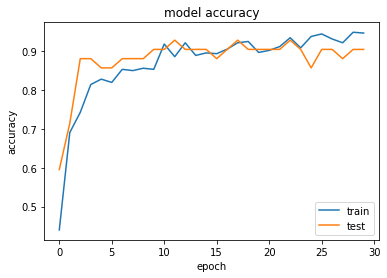

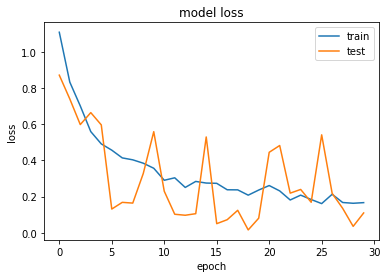

In [ ]:
plot_train_results(mod_ft_fit)

Veamos el valor de "accuracy" alcanzado:

In [ ]:
loss, accuracy = modelo_ft.evaluate(validation_generator, batch_size=BATCH_SIZE)

print(f"Test Loss:     {loss}")
print(f"Test Accuracy: {accuracy}")

33/33 [==============================] - 2s 56ms/step - loss: 0.3756 - acc: 0.8981
Test Loss:     0.37560349702835083
Test Accuracy: 0.8980952501296997


Accuracy sólo una centésima por encima del anterior (feature extraction). Tendriamos la opción de aumentar los epochs y utilizar  "Early Stopping", pero parecería que no habría mucha diferencia tampoco.

###Mapa de características

Extraemos ahora un mapa de características de este modelo a partir del modelo "cnn_base" con VGG:

In [ ]:
modelo_ft.summary()


Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 8, 8, 512)         14714688  
                                                                 
 flatten_4 (Flatten)         (None, 32768)             0         
                                                                 
 dense_7 (Dense)             (None, 512)               16777728  
                                                                 
 dense_8 (Dense)             (None, 21)                10773     
                                                                 
Total params: 31503189 (120.18 MB)
Trainable params: 23867925 (91.05 MB)
Non-trainable params: 7635264 (29.13 MB)
_________________________________________________________________


In [ ]:
cnn_base.summary()

Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 256, 256, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 256, 256, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 256, 256, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 128, 128, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 128, 128, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 128, 128, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 64, 64, 128)       0     

In [ ]:
# Nos cremos un modelo
from keras import Model

layer_out = cnn_base.get_layer("block5_conv3")
intermediate_layer_model = Model(inputs=cnn_base.input,outputs=layer_out.output)



/content/split/test/airplane/airplane15.tif


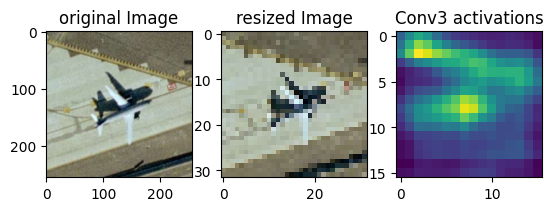

In [ ]:
# CÓDIGO PARA DIBUJAR EL MAPA DE CARACTERÍSTICAS DE LA CLASE "AVIÓN"

path_data = '/content/split/test'
c = 'airplane'
filenames_validation = [os.path.join(path_data, f) for f in validation_generator.filenames if c in f]
np.random.shuffle(filenames_validation)
print(filenames_validation[0])
image = cv2.imread(filenames_validation[0])
image_vis = cv2.resize(image, (32,32))

# normalize image
x = image.astype(np.float)/255

# extract features
features = intermediate_layer_model(np.expand_dims(x, 0)).numpy()[0]

# sum activation across channels
activations = features.sum(-1)

# display original and activations
plt.subplot(1,3,1), plt.imshow(image[:,:,::-1])
plt.title('original Image')
plt.subplot(1,3,2), plt.imshow(image_vis[:,:,::-1])
plt.title('resized Image')
plt.subplot(1,3,3), plt.imshow(activations)
plt.title('Conv3 activations')
plt.show()


##GUARDAR MODELOS

Guardamos los dos últimos modelos:

In [ ]:
modelo_fe.save('/content/vgg_feature_extraction.h5')

In [ ]:
modelo_ft.save('/content/vgg_fine_tunning.h5')